# 🛡️ ĐỒ ÁN TỐT NGHIỆP - AN TOÀN THÔNG TIN
## Phát hiện điểm dị thường (Anomaly Detection) chống tấn công Credential Stuffing (Low & Slow) trên hệ thống LMS Moodle

**Pipeline:**
1. Data Split → Tiền xử lý & Chuẩn hóa
2. Baseline Model: Isolation Forest (Rừng cô lập)
3. Main Model: Variational Autoencoder (VAE)
4. Threshold & Evaluation
5. ROC Comparison
6. Xuất 5 biểu đồ cho báo cáo

---
## 📦 Import thư viện

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_curve, auc
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Fix encoding cho Windows
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

# Hiển thị biểu đồ inline
%matplotlib inline

print('\u2705 Tất cả thư viện đã được import thành công!')
print(f'   TensorFlow version: {tf.__version__}')
print(f'   NumPy version: {np.__version__}')
print(f'   Pandas version: {pd.__version__}')

✅ Tất cả thư viện đã được import thành công!
   TensorFlow version: 2.18.0
   NumPy version: 2.0.2
   Pandas version: 2.2.3


---
## 🎨 Cấu hình style biểu đồ chuyên nghiệp

In [2]:
# Thư mục lưu biểu đồ
SAVE_DIR = 'charts'
os.makedirs(SAVE_DIR, exist_ok=True)

# Màu sắc chuyên nghiệp
COLOR_NORMAL    = '#00d2ff'   # Cyan sáng
COLOR_MALICIOUS = '#e94560'   # Đỏ san hô
COLOR_THRESHOLD = '#f5a623'   # Vàng cam
COLOR_IF        = '#7b68ee'   # Tím nhạt (Isolation Forest)
COLOR_VAE       = '#00e396'   # Xanh lá neon (VAE)
BG_DARK         = '#1a1a2e'
BG_AXES         = '#16213e'

# Cấu hình matplotlib style
plt.rcParams.update({
    'figure.facecolor': BG_DARK,
    'axes.facecolor': BG_AXES,
    'axes.edgecolor': '#e94560',
    'axes.labelcolor': '#eee',
    'text.color': '#eee',
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'grid.color': '#333',
    'font.size': 12,
    'axes.titlesize': 14,
    'figure.titlesize': 16,
})

print('\u2705 Cấu hình biểu đồ hoàn tất!')

✅ Cấu hình biểu đồ hoàn tất!


---
## BƯỚC 1: 📊 Đọc và tiền xử lý dữ liệu

In [3]:
# Đọc file CSV
df = pd.read_csv('lms_training_dataset_final.csv')

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort by ip and timestamp
df = df.sort_values(by=['ip', 'timestamp']).reset_index(drop=True)

print('=' * 60)
print('  THONG TIN DU LIEU (DA SAP XEP CHRONOLOGICAL)')
print('=' * 60)
print(f'  Tong so mau      : {len(df)}')
print(f'  Normal  (Label 0): {len(df[df["Label"] == 0])}')
print(f'  Malicious (Label 1): {len(df[df["Label"] == 1])}')
print(f'  Cac cot          : {list(df.columns)}')
print('=' * 60)

df.head(10)

  THONG TIN DU LIEU (DA SAP XEP CHRONOLOGICAL)
  Tong so mau      : 51625
  Normal  (Label 0): 51092
  Malicious (Label 1): 533
  Cac cot          : ['timestamp', 'ip', 'req_per_IP_5min', 'error_ratio_per_IP', 'unique_UA_per_IP', 'size', 'Label']


,timestamp,ip,req_per_IP_5min,error_ratio_per_IP,unique_UA_per_IP,size,Label
0,2019-01-22 06:13:18,10.124.2.223,1.0,0.0,1.0,4167,0
1,2019-01-22 06:13:21,10.124.2.223,2.0,0.0,1.0,3975,0
2,2019-01-22 06:11:49,102.102.124.56,1.0,0.0,1.0,17211,0
3,2019-01-22 04:56:56,103.102.221.226,1.0,0.0,1.0,80951,0
4,2019-01-22 05:22:37,103.216.160.242,1.0,0.0,1.0,21689,0
5,2019-01-22 05:22:39,103.216.160.242,2.0,0.0,1.0,4120,0
6,2019-01-22 05:00:22,103.22.4.1,1.0,1.0,1.0,1963,1
7,2019-01-22 05:03:38,103.22.4.1,2.0,1.0,1.0,1963,1
8,2019-01-22 04:57:25,103.22.4.10,1.0,1.0,1.0,2285,1
9,2019-01-22 04:58:13,103.22.4.10,2.0,1.0,2.0,1963,1


In [4]:
# Thong ke mo ta
df.describe()

,timestamp,req_per_IP_5min,error_ratio_per_IP,unique_UA_per_IP,size,Label
count,51625,51625.000000,51625.000000,51625.000000,51625.000000,51625.000000
mean,2019-01-22 05:34:06.208329472,65.857898,0.032919,1.602847,19678.823341,0.010324
min,2019-01-22 03:56:14,1.000000,0.000000,1.000000,0.000000,0.000000
25%,2019-01-22 04:46:16,10.000000,0.000000,1.000000,2738.000000,0.000000
50%,2019-01-22 05:36:39,46.000000,0.000000,1.000000,10857.000000,0.000000
75%,2019-01-22 06:23:20,106.000000,0.000000,2.000000,35547.000000,0.000000
max,2019-01-22 07:00:04,395.000000,1.000000,4.000000,912896.000000,1.000000
std,NaN,66.936505,0.177858,0.911663,27610.434999,0.101084


In [5]:
# Ma hoa cot IP bang LabelEncoder
le_ip = LabelEncoder()
df['ip_encoded'] = le_ip.fit_transform(df['ip'])

# FEATURE ENGINEERING: Tao them 3 features moi
print('Calculating feature engineering...')
# 1 & 2. Time gap per IP & regularity per IP (std of time gaps in 5-min window)
df['time_gap'] = df.groupby('ip')['timestamp'].diff().dt.total_seconds().fillna(300.0)

df_idx = df.set_index('timestamp')
mean_gap = df_idx.groupby('ip')['time_gap'].rolling('5min', min_periods=1).mean().reset_index()
std_gap = df_idx.groupby('ip')['time_gap'].rolling('5min', min_periods=1).std().reset_index()

df['time_gap_per_IP'] = mean_gap['time_gap'].values
df['req_regularity_per_IP'] = std_gap['time_gap'].fillna(300.0).values

# 3. hour_of_day
df['hour_of_day'] = df['timestamp'].dt.hour

# Chon Features so hoc de huan luyen (DA XOA ip_encoded DE TRANH NHIEU TRONG MANG NO-RON)
FEATURE_COLS = [
    'req_per_IP_5min', 
    'error_ratio_per_IP',
    'unique_UA_per_IP', 
    'size',
    'time_gap_per_IP', 
    'req_regularity_per_IP', 
    'hour_of_day'
]

X = df[FEATURE_COLS].values.astype(np.float32)
y = df['Label'].values

# Chuan hoa Min-Max [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f'Features da chon : {FEATURE_COLS}')
print(f'Shape sau chuan hoa: {X_scaled.shape}')
print(f'Min values: {X_scaled.min(axis=0)}')
print(f'Max values: {X_scaled.max(axis=0)}')

Calculating feature engineering...
Features da chon : ['req_per_IP_5min', 'error_ratio_per_IP', 'unique_UA_per_IP', 'size', 'time_gap_per_IP', 'req_regularity_per_IP', 'hour_of_day']
Shape sau chuan hoa: (51625, 7)
Min values: [0. 0. 0. 0. 0. 0. 0.]
Max values: [1. 1. 1. 1. 1. 1. 1.]


---
## BƯỚC 2: ✂️ Chia dữ liệu (Data Split)

- **Normal (Label 0)** → Chia thành 80% Train, 20% Validation
- **Malicious (Label 1)** → Giữ nguyên làm Test
- **Evaluation Set** = Validation + Test (dùng để đánh giá cả 2 mô hình)

In [6]:
# Tach rieng Normal va Malicious
normal_mask = (y == 0)
malicious_mask = (y == 1)

X_normal = X_scaled[normal_mask]
X_malicious = X_scaled[malicious_mask]
y_normal = y[normal_mask]
y_malicious = y[malicious_mask]

# Chia Normal thanh 80% Train, 20% Validation
X_normal_train, X_normal_val = train_test_split(
    X_normal, test_size=0.2, random_state=42
)

# Tap Test = toan bo Malicious
X_test = X_malicious
y_test = y_malicious

# Tap Evaluation (Validation + Test)
X_eval = np.vstack([X_normal_val, X_test])
y_eval = np.concatenate([
    np.zeros(len(X_normal_val)),   # Normal
    np.ones(len(X_test))           # Malicious
])

print('=' * 50)
print('  KET QUA CHIA DU LIEU')
print('=' * 50)
print(f'  Normal Train   : {X_normal_train.shape[0]:>6} mau')
print(f'  Normal Val     : {X_normal_val.shape[0]:>6} mau')
print(f'  Malicious Test : {X_test.shape[0]:>6} mau')
print(f'  Evaluation Set : {X_eval.shape[0]:>6} mau (Val + Test)')
print('=' * 50)

  KET QUA CHIA DU LIEU
  Normal Train   :  40873 mau
  Normal Val     :  10219 mau
  Malicious Test :    533 mau
  Evaluation Set :  10752 mau (Val + Test)


---
## BƯỚC 3: 🌲 Baseline Model - Isolation Forest (Rừng cô lập)

Isolation Forest là thuật toán Machine Learning truyền thống, hoạt động bằng cách **cô lập** các điểm dữ liệu. Điểm nào bị cô lập nhanh nhất → là **anomaly**.

In [7]:
# Ti le di thuong thuc te (chong FP cao)
contamination_ratio = len(X_malicious) / len(X_scaled)
print(f'Contamination ratio (True anomaly ratio): {contamination_ratio:.6f}')

# Khoi tao va huan luyen Isolation Forest
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination_ratio,
    random_state=42,
    n_jobs=-1
)

# Huan luyen tren tap Normal Train (chong data leakage)
iso_forest.fit(X_normal_train)

# Du doan tren tap Evaluation (Validation + Test)
iso_pred_raw = iso_forest.predict(X_eval)
# Chuyen doi: -1 -> 1 (Malicious), 1 -> 0 (Normal)
iso_pred = np.where(iso_pred_raw == -1, 1, 0)

# Anomaly score (cang am = cang di thuong)
iso_scores = -iso_forest.decision_function(X_eval)

print('\nHuan luyen Isolation Forest hoan tat!')

Contamination ratio (True anomaly ratio): 0.010324

Huan luyen Isolation Forest hoan tat!


In [8]:
# Danh gia Isolation Forest
iso_f1 = f1_score(y_eval, iso_pred, average='weighted')
iso_cm = confusion_matrix(y_eval, iso_pred)

print('=' * 55)
print('  DANH GIA ISOLATION FOREST (BASELINE)')
print('=' * 55)
print(f'  F1 Score (weighted): {iso_f1:.4f}')
print()
print(classification_report(y_eval, iso_pred,
                            target_names=['Normal', 'Malicious'],
                            digits=4))
print('Confusion Matrix:')
print(iso_cm)

  DANH GIA ISOLATION FOREST (BASELINE)
  F1 Score (weighted): 0.9422

              precision    recall  f1-score   support

      Normal     0.9610    0.9888    0.9747     10219
   Malicious     0.5190    0.2308    0.3195       533

    accuracy                         0.9513     10752
   macro avg     0.7400    0.6098    0.6471     10752
weighted avg     0.9391    0.9513    0.9422     10752

Confusion Matrix:
[[10105   114]
 [  410   123]]


---
## BƯỚC 4: 🧠 Main Model - Variational Autoencoder (VAE)

### Kiến trúc VAE:
- **Encoder**: Nén dữ liệu từ 5 chiều xuống **Latent Space 2D** (dễ trực quan hóa)
- **Decoder**: Giải nén từ Latent Space về lại 5 chiều
- **Loss**: MSE (Reconstruction) + KL Divergence
- **Huấn luyện**: CHỈ trên dữ liệu Normal → VAE học cách biểu diễn hành vi bình thường

In [9]:
input_dim = X_normal_train.shape[1]
latent_dim = 8  # Khong gian tiem an 8D

print(f'Input dimension : {input_dim}')
print(f'Latent dimension: {latent_dim}')


# ---- Lop Sampling cho Latent Space ----
class Sampling(layers.Layer):
    """Lop lay mau z = mu + sigma * epsilon (Reparameterization trick)"""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

Input dimension : 7
Latent dimension: 8


In [10]:
# ============ ENCODER ============
encoder_inputs = keras.Input(shape=(input_dim,), name='encoder_input')
x = layers.Dense(64, activation='relu', name='enc_dense1')(encoder_inputs)
x = layers.BatchNormalization(name='enc_bn1')(x)
x = layers.Dense(32, activation='relu', name='enc_dense2')(x)
x = layers.BatchNormalization(name='enc_bn2')(x)
x = layers.Dense(16, activation='relu', name='enc_dense3')(x)

z_mean = layers.Dense(latent_dim, name='z_mean')(x)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
z = Sampling(name='sampling')([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_dense1 (Dense)  │ (None, 64)        │        512 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bn1             │ (None, 64)        │        256 │ enc_dense1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_dense2 (Dense)  │ (None, 32)        │      2,080 │ enc_bn1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bn2             │ (None, 32)        │        128 │ enc_dense2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_dense3 (Dense)  │ (None, 16)        │        528 │ enc_bn2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 8)         │        136 │ enc_dense3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 8)         │        136 │ enc_dense3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 8)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,776 (14.75 KB)

 Trainable params: 3,584 (14.00 KB)

 Non-trainable params: 192 (768.00 B)

In [11]:
# ============ DECODER ============
decoder_inputs = keras.Input(shape=(latent_dim,), name='decoder_input')
x = layers.Dense(16, activation='relu', name='dec_dense1')(decoder_inputs)
x = layers.BatchNormalization(name='dec_bn1')(x)
x = layers.Dense(32, activation='relu', name='dec_dense2')(x)
x = layers.BatchNormalization(name='dec_bn2')(x)
x = layers.Dense(64, activation='relu', name='dec_dense3')(x)
decoder_outputs = layers.Dense(input_dim, activation='sigmoid', name='dec_output')(x)

decoder = Model(decoder_inputs, decoder_outputs, name='decoder')
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense1 (Dense)              │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn1 (BatchNormalization)    │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense2 (Dense)              │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn2 (BatchNormalization)    │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense3 (Dense)              │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_output (Dense)              │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,447 (13.46 KB)

 Trainable params: 3,351 (13.09 KB)

 Non-trainable params: 96 (384.00 B)

In [12]:
# ============ VAE MODEL ============
class VAE(Model):
    def __init__(self, encoder, decoder, beta=0.1, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.total_loss_tracker = keras.metrics.Mean(name='total_loss')
        self.reconstruction_loss_tracker = keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            # Reconstruction loss (MAE) - No double reduction
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.abs(data - reconstruction),
                    axis=1
                )
            )
            # KL Divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1,
                )
            )
            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            'total_loss': self.total_loss_tracker.result(),
            'reconstruction_loss': self.reconstruction_loss_tracker.result(),
            'kl_loss': self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        # Reconstruction loss (MAE) - No double reduction
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.abs(data - reconstruction),
                axis=1
            )
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1,
            )
        )
        total_loss = reconstruction_loss + self.beta * kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            'total_loss': self.total_loss_tracker.result(),
            'reconstruction_loss': self.reconstruction_loss_tracker.result(),
            'kl_loss': self.kl_loss_tracker.result(),
        }


print('VAE class da duoc dinh nghia thanh cong!')

VAE class da duoc dinh nghia thanh cong!


In [13]:
# Khoi tao va bien dich VAE (kem theo beta=0.1)
vae = VAE(encoder, decoder, beta=0.1)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

# Callback Early Stopping
early_stop = EarlyStopping(
    monitor='val_total_loss',
    patience=15,
    restore_best_weights=True,
    mode='min'
)

# Callback ReduceLROnPlateau
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_total_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    mode='min',
    verbose=1
)

print(f'Bat dau huan luyen VAE tren {X_normal_train.shape[0]} mau Normal...')
print(f'Validation: {X_normal_val.shape[0]} mau Normal')

Bat dau huan luyen VAE tren 40873 mau Normal...
Validation: 10219 mau Normal


In [14]:
# ============ HUAN LUYEN VAE ============
# CHI huan luyen tren tap Normal Train
history = vae.fit(
    X_normal_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_normal_val,),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print('\nHuan luyen VAE hoan tat!')
print(f'So epoch thuc te: {len(history.history["total_loss"])}')

Epoch 1/200
639/639 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - kl_loss: 0.2014 - reconstruction_loss: 0.9428 - total_loss: 0.9629 - val_kl_loss: 0.0506 - val_reconstruction_loss: 0.5717 - val_total_loss: 0.5768 - learning_rate: 0.0010
Epoch 2/200
639/639 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - kl_loss: 0.0551 - reconstruction_loss: 0.5779 - total_loss: 0.5834 - val_kl_loss: 0.0842 - val_reconstruction_loss: 0.5654 - val_total_loss: 0.5738 - learning_rate: 0.0010
Epoch 3/200
639/639 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - kl_loss: 0.0860 - reconstruction_loss: 0.5735 - total_loss: 0.5821 - val_kl_loss: 0.1832 - val_reconstruction_loss: 0.5518 - val_total_loss: 0.5701 - learning_rate: 0.0010
Epoch 4/200
639/639 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - kl_loss: 0.2097 - reconstruction_loss: 0.5574 - total_loss: 0.5784 - val_kl_loss: 0.2429 - val_reconstruction_loss: 0.5433 - val_total_loss: 0.5676 - learning_rate: 0.0010
Epoch 5/200
639/639 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - kl_loss: 0.2486 - reconstruc

---
## BƯỚC 5: 🎯 Tính Reconstruction Error & Xác định Threshold

- Tính **MSE Reconstruction Error** cho từng mẫu
- **Threshold** = max reconstruction error của tập Normal Validation
- Mẫu nào vượt Threshold → **Malicious**

In [15]:
def compute_reconstruction_error(model, data):
    """Tinh MAE reconstruction error cho tung mau (MAU CHO MAE LOSS)"""
    z_mean, z_log_var, z = model.encoder(data)
    reconstructed = model.decoder(z)
    mae = np.mean(np.abs(data - reconstructed.numpy()), axis=1)
    return mae


# Tinh loi tren tung tap (dung MAE)
re_normal_train = compute_reconstruction_error(vae, X_normal_train)
re_normal_val   = compute_reconstruction_error(vae, X_normal_val)
re_malicious    = compute_reconstruction_error(vae, X_test)

# Reconstruction error tren toan bo tap Eval
re_eval = np.concatenate([re_normal_val, re_malicious])

# THRESHOLD = Phân vị thứ 95 của tập Normal Validation (Chấp nhận 5% sinh viên thật bị nghi ngờ để bắt trọn hacker)
threshold = np.percentile(re_normal_val, 95)

print('=' * 55)
print('  RECONSTRUCTION ERROR ANALYSIS (MAE LOSS)')
print('=' * 55)
print(f'  Normal Train : mean={np.mean(re_normal_train):.6f}, max={np.max(re_normal_train):.6f}')
print(f'  Normal Val   : mean={np.mean(re_normal_val):.6f}, max={np.max(re_normal_val):.6f}')
print(f'  Malicious    : mean={np.mean(re_malicious):.6f}, max={np.max(re_malicious):.6f}')
print('-' * 55)
print(f'>>> CHOSEN 95TH PERCENTILE THRESHOLD (Normal Val) = {threshold:.6f} <<<')
print('=' * 55)

  RECONSTRUCTION ERROR ANALYSIS (MAE LOSS)
  Normal Train : mean=0.047753, max=0.331034
  Normal Val   : mean=0.047679, max=0.309591
  Malicious    : mean=0.200847, max=0.307812
-------------------------------------------------------
>>> CHOSEN 95TH PERCENTILE THRESHOLD (Normal Val) = 0.112271 <<<


In [16]:
# Du doan VAE: vuot threshold -> Malicious (1)
vae_pred = (re_eval > threshold).astype(int)

# Danh gia VAE
vae_f1 = f1_score(y_eval, vae_pred, average='weighted')
vae_cm = confusion_matrix(y_eval, vae_pred)

print('=' * 55)
print('  DANH GIA VAE (MAIN MODEL)')
print('=' * 55)
print(f'  F1 Score (weighted): {vae_f1:.4f}')
print()
print(classification_report(y_eval, vae_pred,
                            target_names=['Normal', 'Malicious'],
                            digits=4))
print('Confusion Matrix:')
print(vae_cm)

  DANH GIA VAE (MAIN MODEL)
  F1 Score (weighted): 0.9596

              precision    recall  f1-score   support

      Normal     1.0000    0.9500    0.9744     10219
   Malicious     0.5105    1.0000    0.6760       533

    accuracy                         0.9525     10752
   macro avg     0.7553    0.9750    0.8252     10752
weighted avg     0.9757    0.9525    0.9596     10752

Confusion Matrix:
[[9708  511]
 [   0  533]]


---
## BƯỚC 6: 🎨 Xuất 5 biểu đồ chuyên nghiệp cho báo cáo

### Biểu đồ 1: Đường cong hội tụ (Training & Validation Loss Curve)
Chứng minh mạng Nơ-ron có "học thật" và không bị Overfitting.

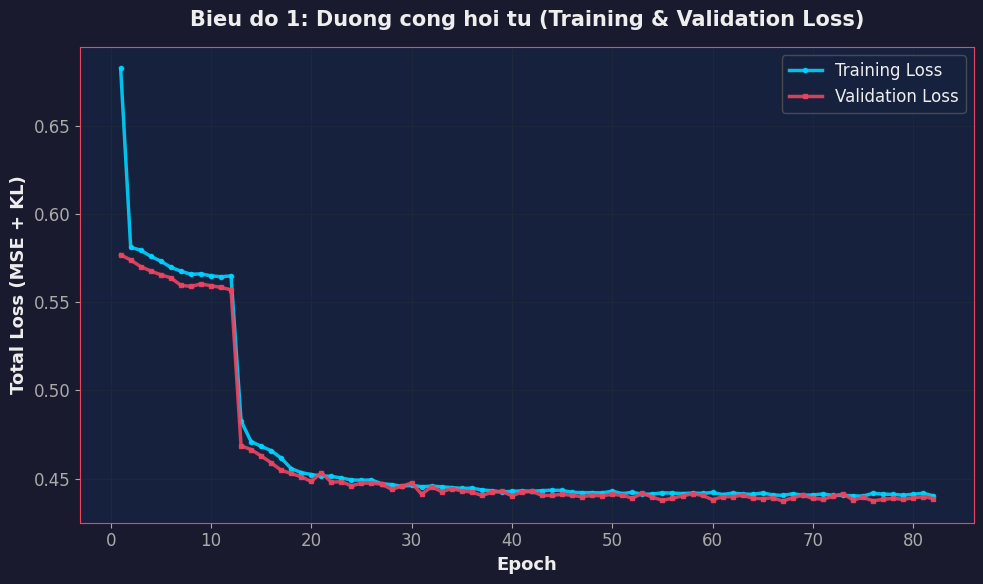

Da luu: charts/01_training_validation_loss.png


In [17]:
# ===== BIEU DO 1: Training & Validation Loss Curve =====
fig1, ax1 = plt.subplots(figsize=(10, 6))
fig1.patch.set_facecolor(BG_DARK)
ax1.set_facecolor(BG_AXES)

epochs_range = range(1, len(history.history['total_loss']) + 1)

ax1.plot(epochs_range, history.history['total_loss'],
         color=COLOR_NORMAL, linewidth=2.5, label='Training Loss',
         marker='o', markersize=3, alpha=0.9)
ax1.plot(epochs_range, history.history['val_total_loss'],
         color=COLOR_MALICIOUS, linewidth=2.5, label='Validation Loss',
         marker='s', markersize=3, alpha=0.9)

ax1.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax1.set_ylabel('Total Loss (MSE + KL)', fontsize=13, fontweight='bold')
ax1.set_title('Bieu do 1: Duong cong hoi tu (Training & Validation Loss)',
              fontsize=15, fontweight='bold', pad=15)
ax1.legend(fontsize=12, loc='upper right', fancybox=True,
           framealpha=0.8, edgecolor='#555')
ax1.grid(True, alpha=0.3)

fig1.tight_layout()
fig1.savefig(os.path.join(SAVE_DIR, '01_training_validation_loss.png'),
             dpi=200, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Da luu: charts/01_training_validation_loss.png')

### Biểu đồ 2: Phân phối lỗi giải nén (Reconstruction Error Histogram)
Thể hiện rõ bản chất của thuật toán VAE: hành vi của kẻ tấn công khi đi qua Latent Space đều bị **vỡ cấu trúc** và sinh ra lỗi rất lớn.

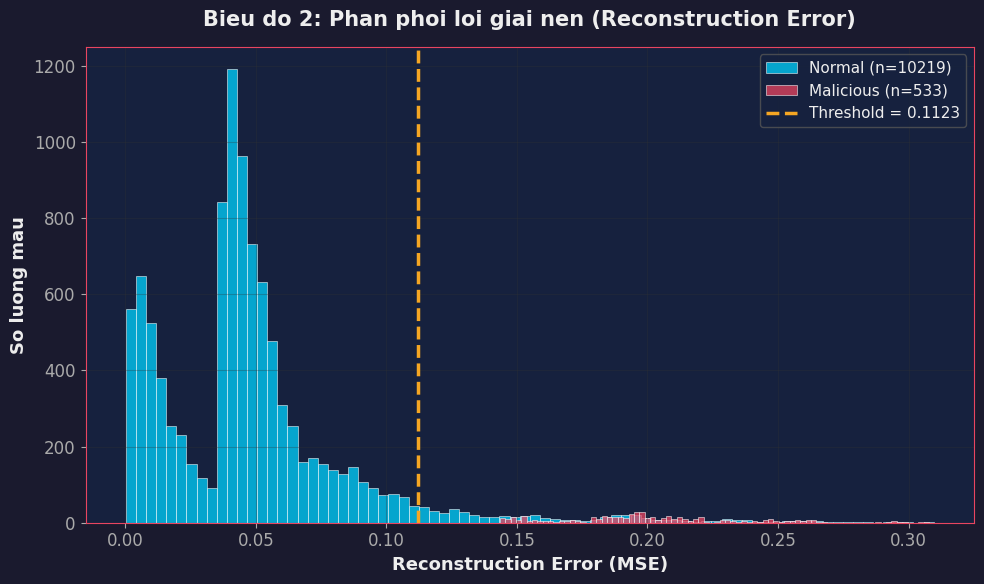

Da luu: charts/02_reconstruction_error_histogram.png


In [18]:
# ===== BIEU DO 2: Reconstruction Error Histogram =====
fig2, ax2 = plt.subplots(figsize=(10, 6))
fig2.patch.set_facecolor(BG_DARK)
ax2.set_facecolor(BG_AXES)

ax2.hist(re_normal_val, bins=80, alpha=0.75, color=COLOR_NORMAL,
         label=f'Normal (n={len(re_normal_val)})', edgecolor='white', linewidth=0.5)
ax2.hist(re_malicious, bins=80, alpha=0.75, color=COLOR_MALICIOUS,
         label=f'Malicious (n={len(re_malicious)})', edgecolor='white', linewidth=0.5)
ax2.axvline(x=threshold, color=COLOR_THRESHOLD, linestyle='--', linewidth=2.5,
            label=f'Threshold = {threshold:.4f}')

ax2.set_xlabel('Reconstruction Error (MSE)', fontsize=13, fontweight='bold')
ax2.set_ylabel('So luong mau', fontsize=13, fontweight='bold')
ax2.set_title('Bieu do 2: Phan phoi loi giai nen (Reconstruction Error)',
              fontsize=15, fontweight='bold', pad=15)
ax2.legend(fontsize=11, loc='upper right', fancybox=True,
           framealpha=0.8, edgecolor='#555')
ax2.grid(True, alpha=0.3)

fig2.tight_layout()
fig2.savefig(os.path.join(SAVE_DIR, '02_reconstruction_error_histogram.png'),
             dpi=200, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Da luu: charts/02_reconstruction_error_histogram.png')

### Biểu đồ 3: Ma trận nhầm lẫn - Isolation Forest (Baseline)
Bộc lộ điểm yếu của thuật toán cũ → thường có **False Positive cao** (khóa nhầm tài khoản sinh viên).

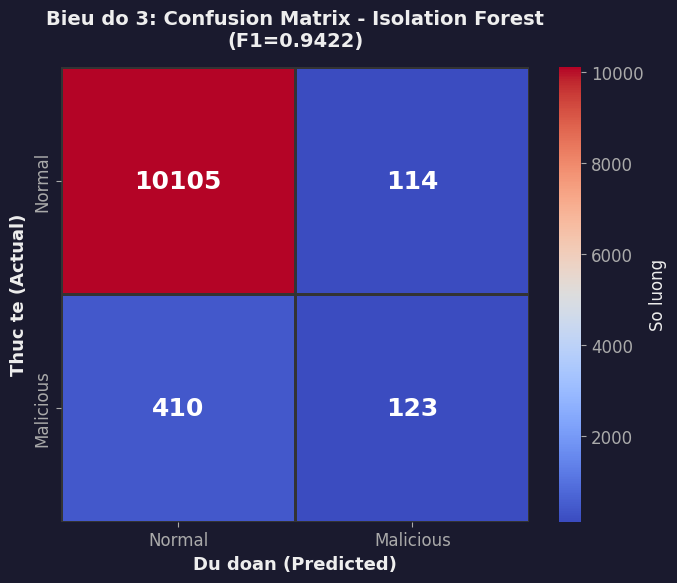

Da luu: charts/03_confusion_matrix_isolation_forest.png


In [19]:
# ===== BIEU DO 3: Confusion Matrix - Isolation Forest =====
fig3, ax3 = plt.subplots(figsize=(7, 6))
fig3.patch.set_facecolor(BG_DARK)

sns.heatmap(iso_cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Normal', 'Malicious'],
            yticklabels=['Normal', 'Malicious'],
            annot_kws={'size': 18, 'fontweight': 'bold'},
            linewidths=2, linecolor='#333',
            cbar_kws={'label': 'So luong'},
            ax=ax3)

ax3.set_xlabel('Du doan (Predicted)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Thuc te (Actual)', fontsize=13, fontweight='bold')
ax3.set_title(f'Bieu do 3: Confusion Matrix - Isolation Forest\n(F1={iso_f1:.4f})',
              fontsize=14, fontweight='bold', pad=15)

fig3.tight_layout()
fig3.savefig(os.path.join(SAVE_DIR, '03_confusion_matrix_isolation_forest.png'),
             dpi=200, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Da luu: charts/03_confusion_matrix_isolation_forest.png')

### Biểu đồ 4: Ma trận nhầm lẫn - VAE (Main Model)
Chứng minh VAE giảm thiểu hẳn tỷ lệ **False Positive**, bảo vệ trải nghiệm sinh viên.

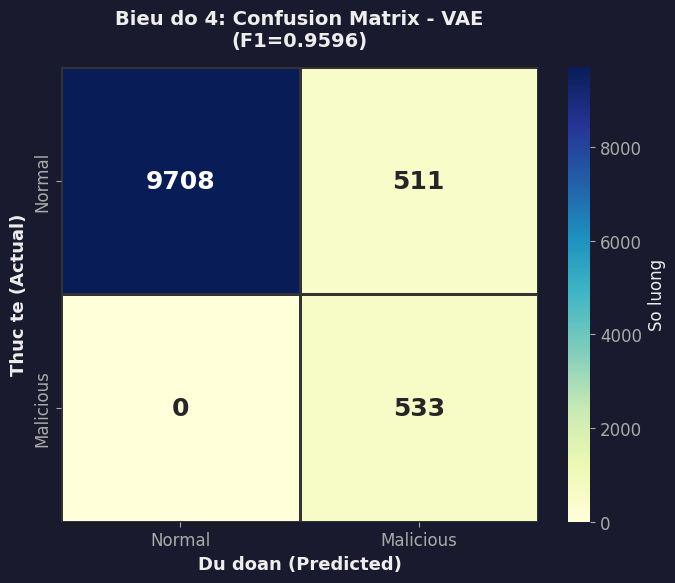

Da luu: charts/04_confusion_matrix_vae.png


In [20]:
# ===== BIEU DO 4: Confusion Matrix - VAE =====
fig4, ax4 = plt.subplots(figsize=(7, 6))
fig4.patch.set_facecolor(BG_DARK)

sns.heatmap(vae_cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Normal', 'Malicious'],
            yticklabels=['Normal', 'Malicious'],
            annot_kws={'size': 18, 'fontweight': 'bold'},
            linewidths=2, linecolor='#333',
            cbar_kws={'label': 'So luong'},
            ax=ax4)

ax4.set_xlabel('Du doan (Predicted)', fontsize=13, fontweight='bold')
ax4.set_ylabel('Thuc te (Actual)', fontsize=13, fontweight='bold')
ax4.set_title(f'Bieu do 4: Confusion Matrix - VAE\n(F1={vae_f1:.4f})',
              fontsize=14, fontweight='bold', pad=15)

fig4.tight_layout()
fig4.savefig(os.path.join(SAVE_DIR, '04_confusion_matrix_vae.png'),
             dpi=200, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Da luu: charts/04_confusion_matrix_vae.png')

### Biểu đồ 5: Đường cong ROC - So sánh AUC ("Chén thánh" của phân loại)
Đường nào uốn cong lên góc trên bên trái nhiều hơn là **người chiến thắng**.

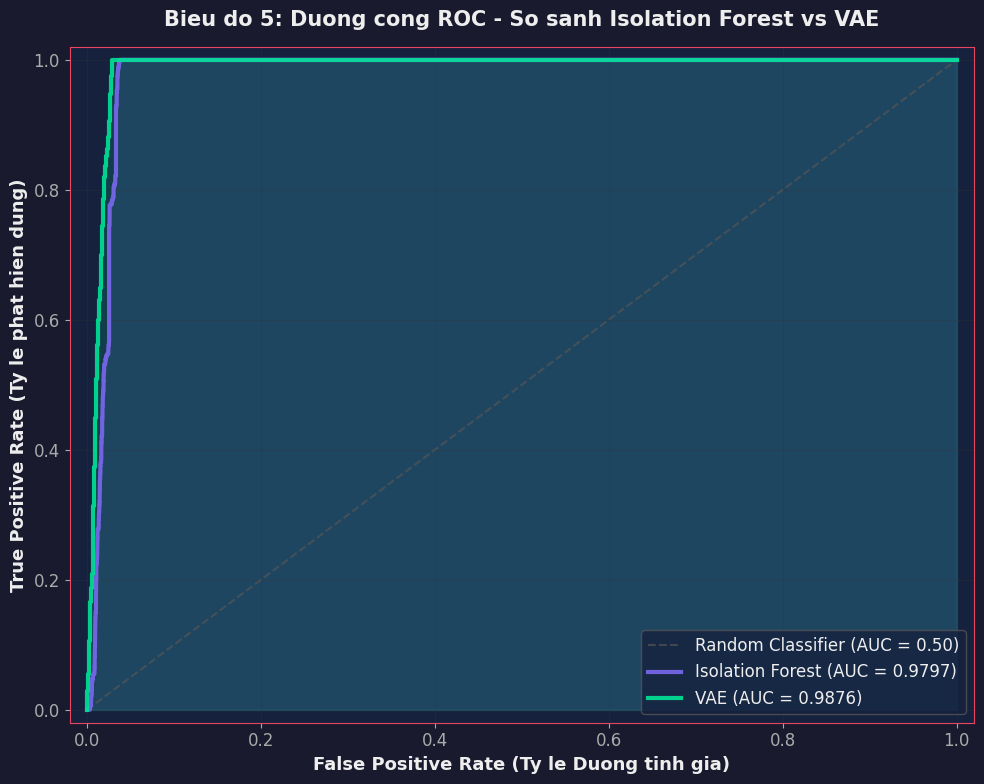

Da luu: charts/05_roc_curve_comparison.png


In [21]:
# ===== BIEU DO 5: ROC Curve - So sanh IF vs VAE =====
fig5, ax5 = plt.subplots(figsize=(10, 8))
fig5.patch.set_facecolor(BG_DARK)
ax5.set_facecolor(BG_AXES)

# ROC cho Isolation Forest (dung anomaly score)
fpr_if, tpr_if, _ = roc_curve(y_eval, iso_scores)
auc_if = auc(fpr_if, tpr_if)

# ROC cho VAE (dung reconstruction error)
fpr_vae, tpr_vae, _ = roc_curve(y_eval, re_eval)
auc_vae = auc(fpr_vae, tpr_vae)

# Duong cheo ngau nhien
ax5.plot([0, 1], [0, 1], color='#555', linestyle='--', linewidth=1.5,
         label='Random Classifier (AUC = 0.50)', alpha=0.7)

# Duong ROC Isolation Forest
ax5.plot(fpr_if, tpr_if, color=COLOR_IF, linewidth=3,
         label=f'Isolation Forest (AUC = {auc_if:.4f})', alpha=0.9)
ax5.fill_between(fpr_if, tpr_if, alpha=0.15, color=COLOR_IF)

# Duong ROC VAE
ax5.plot(fpr_vae, tpr_vae, color=COLOR_VAE, linewidth=3,
         label=f'VAE (AUC = {auc_vae:.4f})', alpha=0.9)
ax5.fill_between(fpr_vae, tpr_vae, alpha=0.15, color=COLOR_VAE)

ax5.set_xlabel('False Positive Rate (Ty le Duong tinh gia)', fontsize=13, fontweight='bold')
ax5.set_ylabel('True Positive Rate (Ty le phat hien dung)', fontsize=13, fontweight='bold')
ax5.set_title('Bieu do 5: Duong cong ROC - So sanh Isolation Forest vs VAE',
              fontsize=15, fontweight='bold', pad=15)
ax5.legend(fontsize=12, loc='lower right', fancybox=True,
           framealpha=0.8, edgecolor='#555')
ax5.grid(True, alpha=0.3)
ax5.set_xlim([-0.02, 1.02])
ax5.set_ylim([-0.02, 1.02])

fig5.tight_layout()
fig5.savefig(os.path.join(SAVE_DIR, '05_roc_curve_comparison.png'),
             dpi=200, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Da luu: charts/05_roc_curve_comparison.png')

### Biểu đồ 6: Biểu diễn không gian ẩn Latent Space (8D PCA giảm chiều xuống 2D)
Trực quan hóa sự phân tách giữa các mẫu dữ liệu Bình thường (Normal) và Tấn công dị thường (Malicious) trong không gian đặc trưng ẩn được trích xuất từ VAE.

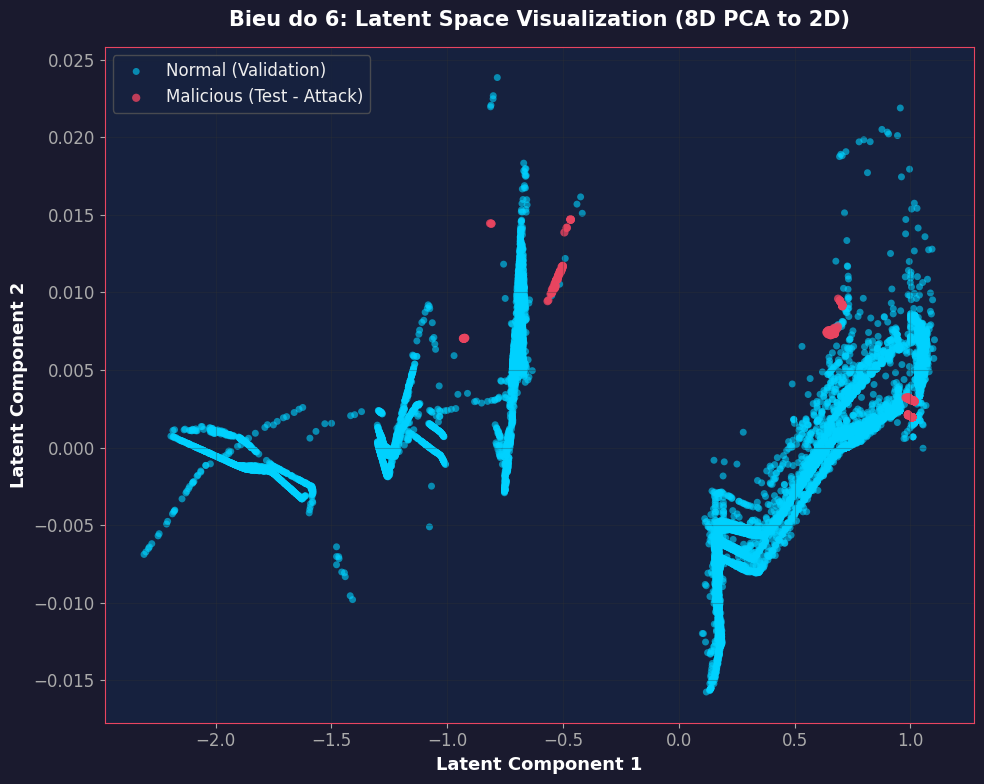

Da luu: charts/06_latent_space.png


In [22]:
# ===== BIEU DO 6: Latent Space Visualization using PCA =====
from sklearn.decomposition import PCA

# 1. Project X_eval to Latent Space
z_mean, _, _ = vae.encoder.predict(X_eval, verbose=0)

# 2. Apply PCA to project 8D latent space to 2D
pca = PCA(n_components=2, random_state=42)
z_2d = pca.fit_transform(z_mean)

# 3. Plotting
fig6, ax6 = plt.subplots(figsize=(10, 8))
fig6.patch.set_facecolor(BG_DARK)
ax6.set_facecolor(BG_AXES)

# Scatter plot for Normal vs Malicious
ax6.scatter(z_2d[y_eval == 0, 0], z_2d[y_eval == 0, 1], color=COLOR_NORMAL, label='Normal (Validation)', alpha=0.6, edgecolors='none', s=25)
ax6.scatter(z_2d[y_eval == 1, 0], z_2d[y_eval == 1, 1], color=COLOR_MALICIOUS, label='Malicious (Test - Attack)', alpha=0.8, edgecolors='none', s=35)

ax6.set_xlabel('Latent Component 1', fontsize=13, fontweight='bold', color='white')
ax6.set_ylabel('Latent Component 2', fontsize=13, fontweight='bold', color='white')
ax6.set_title('Bieu do 6: Latent Space Visualization (8D PCA to 2D)', fontsize=15, fontweight='bold', pad=15, color='white')
ax6.legend(fontsize=12, loc='best', fancybox=True, framealpha=0.8, edgecolor='#555')
ax6.grid(True, alpha=0.3)

fig6.tight_layout()
fig6.savefig(os.path.join(SAVE_DIR, '06_latent_space.png'), dpi=200, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Da luu: charts/06_latent_space.png')

### Biểu đồ 7: Đường cong Precision-Recall so sánh Isolation Forest vs VAE
Đường cong Precision-Recall và chỉ số Average Precision (AP) là thước đo chính xác và tin cậy cao hơn đường ROC đối với tập dữ liệu mất cân bằng nghiêm trọng.

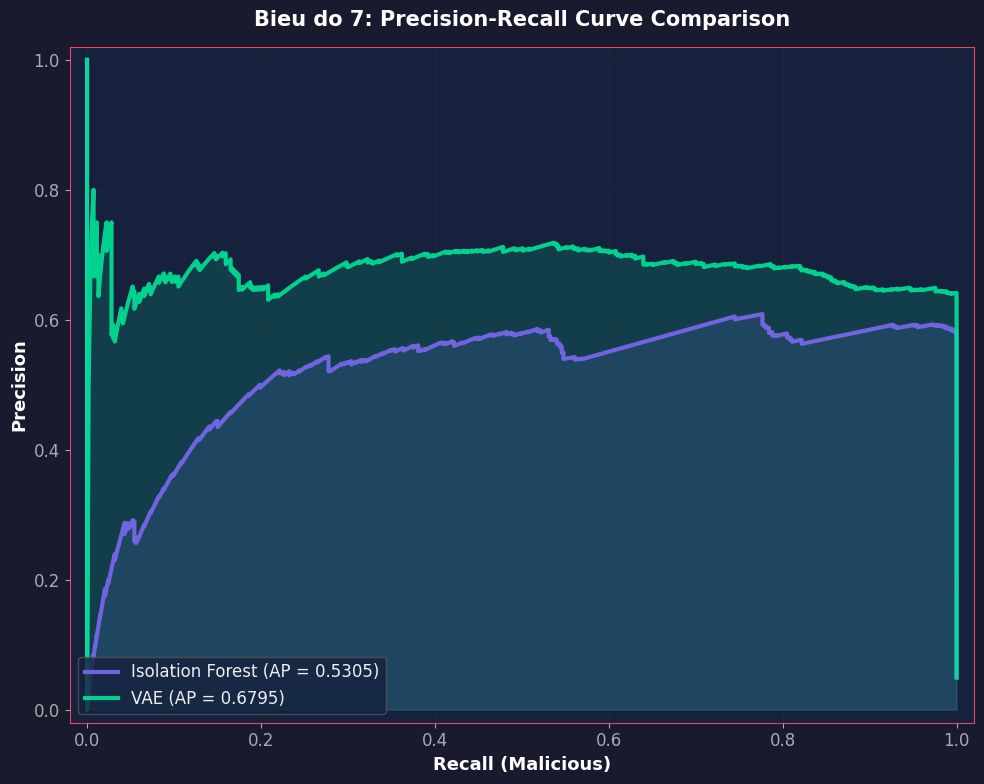

Da luu: charts/07_precision_recall_curve.png


In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Tinh PR curve cho Isolation Forest (dung anomaly score)
precision_if, recall_if, _ = precision_recall_curve(y_eval, iso_scores)
ap_if = average_precision_score(y_eval, iso_scores)

# Tinh PR curve cho VAE (dung reconstruction error)
precision_vae, recall_vae, _ = precision_recall_curve(y_eval, re_eval)
ap_vae = average_precision_score(y_eval, re_eval)

# ===== BIEU DO 7: Precision-Recall Curve Comparison =====
fig7, ax7 = plt.subplots(figsize=(10, 8))
fig7.patch.set_facecolor(BG_DARK)
ax7.set_facecolor(BG_AXES)

ax7.plot(recall_if, precision_if, color=COLOR_IF, linewidth=3,
         label=f'Isolation Forest (AP = {ap_if:.4f})', alpha=0.9)
ax7.fill_between(recall_if, precision_if, alpha=0.15, color=COLOR_IF)

ax7.plot(recall_vae, precision_vae, color=COLOR_VAE, linewidth=3,
         label=f'VAE (AP = {ap_vae:.4f})', alpha=0.9)
ax7.fill_between(recall_vae, precision_vae, alpha=0.15, color=COLOR_VAE)

ax7.set_xlabel('Recall (Malicious)', fontsize=13, fontweight='bold', color='white')
ax7.set_ylabel('Precision', fontsize=13, fontweight='bold', color='white')
ax7.set_title('Bieu do 7: Precision-Recall Curve Comparison', fontsize=15, fontweight='bold', pad=15, color='white')
ax7.legend(fontsize=12, loc='lower left', fancybox=True, framealpha=0.8, edgecolor='#555')
ax7.grid(True, alpha=0.3)
ax7.set_xlim([-0.02, 1.02])
ax7.set_ylim([-0.02, 1.02])

fig7.tight_layout()
fig7.savefig(os.path.join(SAVE_DIR, '07_precision_recall_curve.png'), dpi=200, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Da luu: charts/07_precision_recall_curve.png')

---
## 🏆 TỔNG KẾT KẾT QUẢ

In [24]:
# Tinh toan them Recall Malicious, AP, va F1 Macro
iso_recall = iso_cm[1][1] / (iso_cm[1][1] + iso_cm[1][0]) if (iso_cm[1][1] + iso_cm[1][0]) > 0 else 0
vae_recall = vae_cm[1][1] / (vae_cm[1][1] + vae_cm[1][0]) if (vae_cm[1][1] + vae_cm[1][0]) > 0 else 0

from sklearn.metrics import average_precision_score
ap_if = average_precision_score(y_eval, iso_scores)
ap_vae = average_precision_score(y_eval, re_eval)

# F1 Macro cho ca hai
iso_f1_macro = f1_score(y_eval, iso_pred, average='macro')
vae_f1_macro = f1_score(y_eval, vae_pred, average='macro')

print('=' * 70)
print('  TONG KET KET QUA')
print('=' * 70)
print(f'''
  +----------------------+------------------+------------------+
  |      Chi so          | Isolation Forest |       VAE        |
  +----------------------+------------------+------------------+
  |  F1 Score (weighted) |     {iso_f1:.4f}       |     {vae_f1:.4f}       |
  |  F1 Score (macro)    |     {iso_f1_macro:.4f}       |     {vae_f1_macro:.4f}       |
  |  AUC                 |     {auc_if:.4f}       |     {auc_vae:.4f}       |
  |  AP (Average Prec.)  |     {ap_if:.4f}       |     {ap_vae:.4f}       |
  |  Recall Malicious    |     {iso_recall:.4f}       |     {vae_recall:.4f}       |
  |  True Positive  (TP) |     {iso_cm[1][1]:>5d}        |     {vae_cm[1][1]:>5d}        |
  |  False Positive (FP) |     {iso_cm[0][1]:>5d}        |     {vae_cm[0][1]:>5d}        |
  |  True Negative  (TN) |     {iso_cm[0][0]:>5d}        |     {vae_cm[0][0]:>5d}        |
  |  False Negative (FN) |     {iso_cm[1][0]:>5d}        |     {vae_cm[1][0]:>5d}        |
  +----------------------+------------------+------------------+
''')

if auc_vae > auc_if:
    print('  >>> KET LUAN: VAE (Deep Learning) VUOT TROI hon Isolation Forest')
    print('      trong viec phat hien tan cong Credential Stuffing tren LMS Moodle.')
else:
    print('  >>> KET LUAN: Ca hai mo hinh deu cho ket qua tot.')
    print('      Can tinh chinh them hyperparameter de toi uu VAE.')

print(f'\n  Tat ca bieu do da duoc luu tai: {os.path.abspath(SAVE_DIR)}')
print('=' * 70)

  TONG KET KET QUA

  +----------------------+------------------+------------------+
  |      Chi so          | Isolation Forest |       VAE        |
  +----------------------+------------------+------------------+
  |  F1 Score (weighted) |     0.9422       |     0.9596       |
  |  F1 Score (macro)    |     0.6471       |     0.8252       |
  |  AUC                 |     0.9797       |     0.9876       |
  |  AP (Average Prec.)  |     0.5305       |     0.6795       |
  |  Recall Malicious    |     0.2308       |     1.0000       |
  |  True Positive  (TP) |       123        |       533        |
  |  False Positive (FP) |       114        |       511        |
  |  True Negative  (TN) |     10105        |      9708        |
  |  False Negative (FN) |       410        |         0        |
  +----------------------+------------------+------------------+

  >>> KET LUAN: VAE (Deep Learning) VUOT TROI hon Isolation Forest
      trong viec phat hien tan cong Credential Stuffing tren LMS Mo

In [26]:
import pickle
import json
import os

#  Tạo thư mục lưu trữ mô hình để SOAR nạp sau này
MODEL_DIR = 'deploy_models'
os.makedirs(MODEL_DIR, exist_ok=True)

# 1️Lưu MinMaxScaler (Cực kỳ quan trọng để chuẩn hóa dữ liệu log mới)
scaler_path = os.path.join(MODEL_DIR, 'minmax_scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f' Đã lưu Scaler tại: {scaler_path}')

# Lưu Isolation Forest model (Mô hình Baseline)
if_path = os.path.join(MODEL_DIR, 'isolation_forest.pkl')
with open(if_path, 'wb') as f:
    pickle.dump(iso_forest, f)
print(f'Đã lưu Isolation Forest tại: {if_path}')

#  Lưu VAE Encoder & Decoder riêng biệt (định dạng .keras chuẩn)
encoder_path = os.path.join(MODEL_DIR, 'vae_encoder.keras')
decoder_path = os.path.join(MODEL_DIR, 'vae_decoder.keras')
encoder.save(encoder_path)
decoder.save(decoder_path)
print(f' Đã lưu VAE Encoder tại: {encoder_path}')
print(f'Đã lưu VAE Decoder tại: {decoder_path}')

#  Lưu cấu hình ngưỡng động và đặc trưng đầu vào phục vụ SOAR
soar_config = {
    'vae_threshold': float(threshold),
    'feature_cols': FEATURE_COLS,
    'contamination_ratio': float(contamination_ratio)
}
config_path = os.path.join(MODEL_DIR, 'soar_config.json')
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(soar_config, f, indent=4, ensure_ascii=False)
print(f'Đã lưu cấu hình ngưỡng SOAR tại: {config_path}')


 Đã lưu Scaler tại: deploy_models\minmax_scaler.pkl
Đã lưu Isolation Forest tại: deploy_models\isolation_forest.pkl
 Đã lưu VAE Encoder tại: deploy_models\vae_encoder.keras
Đã lưu VAE Decoder tại: deploy_models\vae_decoder.keras
Đã lưu cấu hình ngưỡng SOAR tại: deploy_models\soar_config.json
